In [1]:
#@title
import numpy as np
import ipywidgets as widgets # for the interactive user interface
from ipywidgets import interact, interactive_output, HBox, VBox, Layout
from IPython.display import display, clear_output, SVG, HTML
import graphviz as gv # for visualizing a tree using Digraph
from graphviz import Digraph
import pydot

In [2]:
class TreeNode:
    def __init__(self, key):
        self.key = key
        self.parent = None
        self.left = None
        self.right = None
        self.pos = [0, 0] # Position
        self.col = "black" # Color
        self.h = 0 # Height
    def spos(self):
        ''' Position of a node for neato-Engine '''
        return str(self.pos[0]) + "," + str(self.pos[1]) + "!"
    def to_string(self):
        return str(self.key)
    def print(self):
        print("TreeNode: %d" % (self.key))

n10 = TreeNode(10)
n5 = TreeNode(5)
n14 = TreeNode (14)
n3 = TreeNode(3)

# Create tree by linking the tree nodes
n5.parent = n10; n14.parent = n10
n10.left = n5 # left child
n10.right = n14 # right child
print([n10.to_string(), n10.left.to_string(), n10.right.to_string()])

['10', '5', '14']


In [3]:
#@title
class BST():
    def __init__(self):
        self.root = None # Root of the tree
        self.list = [] # Elements of the tree as list
        
        # Insert a key
    def insert(self, k):
        ''' Insert a key '''
        newNode = TreeNode(k)
        # If the tree is empty, the new node is the root
        if self.root == None:
            self.root = newNode
        else:
            x = self.root
            # Find parent node
            while x != None:
                p = x
                if newNode.key < x.key:
                    x = x.left
                elif newNode.key >= x.key:
                    x = x.right
            # Set parent, left and right child for newNode
            newNode.parent = p
            if newNode.key < p.key:
                p.left = newNode
            else:
                p.right = newNode
            
    def insert_keys(self, keys):
        ''' Insert a set of keys'''
        for k in keys:
            self.insert(k)
            
    def search(self, x, k):
        ''' Search for a key k starting at node x '''
        if (x == None):
            return x
        if (x.key == k):
            x.col = "green" # for visualization: found node is colored green
            return x
        if (k < x.key):
            return self.search(x.left, k)
        else:
            return self.search(x.right, k)
    def find(self, k):
        return self.search(self.root, k)
                    
    def transplant(self, u, v):
        ''' Replace subtree u with subtree v '''
        if (u.parent == None):
            self.root = u
        elif u == u.parent.left:
            u.parent.left = v
        else:
            u.parent.right = v
        if v != None:
            v.parent = u.parent

    def tree_minimum(self, x):
        ''' Determine the smallest key in the subtree of x'''
        while (x.left != None):
            x = x.left
        return x;

    def delete(self, k):
        '''Delete node with key k from tree '''
        z = self.search(self.root, k)
        if z == None:
            return
        if z.left == None: # case 1: z has no left child
            self.transplant(z, z.right)
        elif z.right == None: # case 2: z has no right child
            self.transplant(z, z.left)
        else:
            y = self.tree_minimum(z.right) # determine smallest value in z.right
            if (y.parent != z):
                self.transplant(y, y.right)
                y.right = z.right
                y.right.parent = y
            self.transplant(z, y)
            y.left = z.left
            y.left.parent = y
            if (z == self.root):
                self.root = y

    def rotate_left(self, x):
        ''' Rotate left on node x'''
        y = x.right # set y to be right child
        if y != None:
            x.right = y.left # turn y's left subtree to x's right subtree
        if y.left != None:
            y.left.parent = x
        y.parent = x.parent # link x's parent to y
        if x.parent == None: # Case 1: x is root
            self.root = y
        elif x == x.parent.left: # Case 2: x is left child
            x.parent.left = y
        else: # Case 3: x is right child
            x.parent.right = y
        y.left = x
        x.parent = y

    def rotate_right(self, x):
        ''' Rotate right on node x'''
        y = x.left
        x.left = y.right
        if (y.right != None):
            y.right.parent = x
        y.parent = x.parent
        if (x.parent == None):
            self.root = y
        elif x == x.parent.right:
            x.parent.right = y
        else:
            x.parent.left = y
        y.right = x
        x.parent = y
        
    def height(self, x):
        ''' Height of a tree '''
        if (x == None):
            return 0
        else:
            return 1 + np.maximum(self.height(x.left), self.height(x.right))

    def inorder_traversal(self, x):
        '''Inorder traversal of the tree: returns elements sorted by key '''
        if (x != None):
            if (x == self.root):
                self.list = []
            self.inorder_traversal(x.left)
            self.list.append(x.to_string()) # VISIT()
            self.inorder_traversal(x.right)

    def postorder_traversal(self, x):
        '''Postorder traversal of the tree: left child, right child, root '''
        if (x != None):
            if (x == self.root):
                self.list = []
            self.postorder_traversal(x.left)
            self.postorder_traversal(x.right)
            self.list.append(x.to_string())

In [4]:
class BSTViz:
    ''' Class BSTviz adds a Graphviz visualisation to a BST '''
    ''' Positions of left/right nodes are calculated relatively to the root '''
    def __init__(self, bst):
        self.bst = bst
    def visualize(self):
        ''' Visualize the tree using graphviz '''
        tree = self.bst.root
        dot = Digraph()
        dot.engine = 'neato'
        # Place root node
        h = self.bst.height(tree) # height of the root node
        tree.pos = [0, h]
        dot.node(name=str(tree), label=str(tree.key), color = tree.col, shape="circle",
            fixedsize="True", width="0.4", pos=tree.spos())
        # Recursively place the other nodes and edges
        def add_nodes(tree, dot):
            h = self.bst.height(tree) # height of the current node
            if tree.left: # if left subtree: position node to left of parent
                tree.left.pos[0] = tree.pos[0] - h/4 # x
                tree.left.pos[1] = tree.pos[1] - 0.6 # y
                dot.node(name=str(tree.left), label=str(tree.left.key), color = tree.left.col,
                        shape="circle", fixedsize="True", width="0.4", pos=tree.left.spos())
                dot.edge(str(tree), str(tree.left))
                dot = add_nodes(tree.left, dot=dot)
            if tree.right: # if right subtree: position node to right of parent
                tree.right.pos[0] = tree.pos[0] + h/4 # x
                tree.right.pos[1] = tree.pos[1] - 0.6 # y
                dot.node(name=str(tree.right), label=str(tree.right.key), color = tree.right.col,
                        shape="circle", fixedsize="True", width="0.4", pos=tree.right.spos())
                dot.edge(str(tree), str(tree.right))
                dot = add_nodes(tree.right, dot=dot)
            return dot
        display(add_nodes(tree, dot))

=== Implementasi BST untuk Data Siswa ===
Menyisipkan siswa...
BST setelah penyisipan:


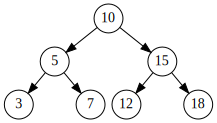

Mencari siswa dengan ID: 7...
Ditemukan: ID: 7, Name: Eko
Mencari siswa dengan ID: 99...
Siswa dengan ID 99 tidak ditemukan.
BST setelah pencarian:


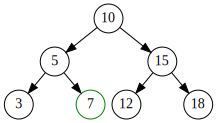

Menghapus siswa dengan ID: 15...
BST setelah penghapusan:


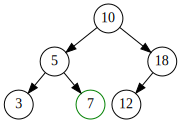

Daftar siswa setelah penghapusan (inorder traversal):
['3', '5', '7', '10', '12', '18']


In [5]:
class Student:
    def __init__(self, student_id, name):
        self.student_id = student_id
        self.name = name

    def __str__(self):
        return f"ID: {self.student_id}, Name: {self.name}"
    
    def __repr__(self):
        return self.__str__()


class BSTStudent(BST):
    """Binary Search Tree implementation for Student objects."""

    def insert(self, student):
        """Insert a Student object into the BST."""
        new_node = TreeNode(student.student_id)
        new_node.student_data = student # Store the actual student object

        if self.root is None:
            self.root = new_node
        else:
            x = self.root
            p = None
            while x is not None:
                p = x
                if new_node.key < x.key:
                    x = x.left
                else:
                    x = x.right

            new_node.parent = p
            if new_node.key < p.key:
                p.left = new_node
            else:
                p.right = new_node

    def search(self, x, student_id):
        """Search for a Student by student_id starting at node x."""
        if x is None or x.key == student_id:
            if x: x.col = "green" # for visualization: found node is colored green
            return x
        if student_id < x.key:
            return self.search(x.left, student_id)
        else:
            return self.search(x.right, student_id)

    def find(self, student_id):
        return self.search(self.root, student_id)

    def delete(self, student_id):
        """Delete node with the given student_id from the tree."""
        z = self.search(self.root, student_id)
        if z is None:
            print(f"Student with ID {student_id} not found.")
            return
        super().delete(student_id) # Use the base BST's delete method

print("=== Implementasi BST untuk Data Siswa ===")

# Buat BST baru untuk siswa
bst_students = BSTStudent()

# Sisipkan data siswa
print("Menyisipkan siswa...")
bst_students.insert(Student(10, "Budi"))
bst_students.insert(Student(5, "Ani"))
bst_students.insert(Student(15, "Candra"))
bst_students.insert(Student(3, "Dewi"))
bst_students.insert(Student(7, "Eko"))
bst_students.insert(Student(12, "Fitri"))
bst_students.insert(Student(18, "Gita"))

# Visualisasi pohon setelah penyisipan
print("BST setelah penyisipan:")
BSTViz(bst_students).visualize()

# Cari siswa
search_id = 7
print(f"Mencari siswa dengan ID: {search_id}...")
found_node = bst_students.find(search_id)
if found_node and hasattr(found_node, 'student_data'):
    print(f"Ditemukan: {found_node.student_data}")
else:
    print(f"Siswa dengan ID {search_id} tidak ditemukan.")

search_id = 99
print(f"Mencari siswa dengan ID: {search_id}...")
found_node = bst_students.find(search_id)
if found_node and hasattr(found_node, 'student_data'):
    print(f"Ditemukan: {found_node.student_data}")
else:
    print(f"Siswa dengan ID {search_id} tidak ditemukan.")

# Visualisasi pohon setelah pencarian (node yang ditemukan akan berwarna hijau)
print("BST setelah pencarian:")
BSTViz(bst_students).visualize()

# Hapus siswa
delete_id = 15
print(f"Menghapus siswa dengan ID: {delete_id}...")
bst_students.delete(delete_id)

# Visualisasi pohon setelah penghapusan
print("BST setelah penghapusan:")
BSTViz(bst_students).visualize()

print("Daftar siswa setelah penghapusan (inorder traversal):")
bst_students.inorder_traversal(bst_students.root)
if bst_students.list:
    # Since the list stores keys, we need to map back to student data if desired
    # For this example, just showing the keys as proof of deletion
    print([key for key in bst_students.list])
else:
    print("BST kosong.")

Insert 10, 3, 5, 2, 12, 11


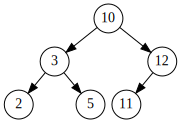

Found: 12


In [6]:
# Test the BST-class
# Create a new tree by inserting random nodes and visualize it
bst = BST()
print("Insert 10, 3, 5, 2, 12, 11")
bst.insert_keys([10, 3, 5, 2, 12, 11])
BSTViz(bst).visualize()
node = bst.find(12)
print("Found: " + node.to_string())

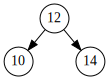

In [7]:
bst = BST()
bst.insert(12)
bst.insert(10)
bst.insert(14)
BSTViz(bst).visualize()

Insert 10, 3, 5, 2, 12, 11
Delete 3:


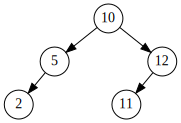

Height of the tree is 3


In [8]:
bst = BST()
print("Insert 10, 3, 5, 2, 12, 11")
bst.insert_keys([10, 3, 5, 2, 12, 11])
print("Delete 3:")
bst.delete(3)
BSTViz(bst).visualize()
print("Height of the tree is %d" % bst.height(bst.root))


In [9]:
bst = BST()
print("Insert 10, 3, 5, 2, 12, 11")
bst.insert_keys([10, 3, 5, 2, 12, 11])
# Create the inorder traversal
bst.inorder_traversal(bst.root)
print(bst.list)
# Create the postorder traversal
bst.postorder_traversal(bst.root)
print(bst.list)


Insert 10, 3, 5, 2, 12, 11
['2', '3', '5', '10', '11', '12']
['2', '5', '3', '11', '12', '10']


Insert 10, 12, 14


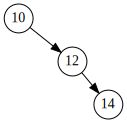

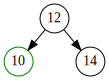

In [10]:
bst = BST()
print("Insert 10, 12, 14")
bst.insert_keys([10, 12, 14])
BSTViz(bst).visualize()
n10 = bst.find(10)
bst.rotate_left(n10)
BSTViz(bst).visualize()

In [11]:
#@title
import ipywidgets as widgets
from ipywidgets import BoundedIntText, Button, HTML, Tab, HBox, VBox, Output
from numpy.random import seed, randint
from datetime import datetime

# Create a new tree
tree = BST()
################################
# Output objects
out, out1, out2, out3 = Output(), Output(), Output(), Output()
tab = Tab(children = [out1, out2, out3],
    layout=Layout(width='100%', height='auto'))
tab.set_title(0, 'Binary search tree')
tab.set_title(1, 'AVL Tree')
tab.set_title(2, 'B-Tree')

###############################
# Input field for keys
ui_key = BoundedIntText(value=20, min=0, max=100,
                        step=2, description='Enter Key:', disabled=False)
################################
# Error messages
msg = "<p>Click on one of the buttons below!</p>"
msg1 = "<p>No tree selected!</p>"
msg2 = "<p>Node not found!!</p>"
################################
# Buttons
btn_insert = Button(description='Insert', button_style='success')

btn_delete = Button(description='Delete', button_style='primary')
def on_button_insert_clicked(b):
    with out:
        clear_output()
        tree.insert(ui_key.value)
        BSTViz(tree).visualize()
btn_insert.on_click(on_button_insert_clicked)

btn_clear = Button(description='Clear', button_style='danger')
def on_button_clear_clicked(b):
    with out:
        clear_output()
        tree.root = None

btn_clear.on_click(on_button_clear_clicked)

btn_search = Button(description='Search', button_style='info')
def on_button_search_clicked(b):
    with out:
        clear_output()
        if (tree is None):
            print("No tree selected!")
        else:
            print("Search: %d" % (ui_key.value))
            foundnode = tree.find(ui_key.value)
            if (foundnode != None):
                print("Found: %d is in tree" % (ui_key.value))
                BSTViz(tree).visualize()
            else:
                print("Not found: %d not in tree" % (ui_key.value))
                BSTViz(tree).visualize()

btn_search.on_click(on_button_search_clicked)

btn_rnd = widgets.Button(description='Random', button_style='warning')
seed(1)
def on_button_rnd_clicked(b):
    with out:
        clear_output()
        tree.root = None
        keys = randint(1, 50, 7)
        print(keys)
        tree.insert_keys(keys)
        BSTViz(tree).visualize()
btn_rnd.on_click(on_button_rnd_clicked)

################################
# Layout
layout_displ=Layout(height='300px', border='1px dotted blue', overflow ='auto')
layout_ctrl=Layout(height='50px')

################################

with out1:
    htm = HTML(msg)
    msgbox = HTML("<p></p>")
    displ = HBox([out], layout=layout_displ)
    ctrl = HBox([ui_key, btn_insert, btn_delete, btn_search, btn_rnd, btn_clear], layout=layout_ctrl)
    display(VBox([displ, htm, msgbox, ctrl]))
with out2:
    htm = HTML(msg1)
    msgbox = HTML("<p></p>")
    displ = HBox([out], layout=layout_displ)
    ctrl = HBox([ui_key, btn_insert, btn_delete, btn_search, btn_rnd, btn_clear], layout=layout_ctrl) 
    display(VBox([displ, htm, msgbox, ctrl]))
with out3:
    htm = HTML("<h1>TODO</h1><p>Insert your code here</p>")
    display(htm)
    
display(tab)
